# Automated Trading using Python

A simple Python algorithmic trading strategy that trades based on forecast differences, i.e., the difference between the day-ahead production forecast and the intraday production forecast. 

### Strategy Logic:
- Buy if intraday production forecast is lower than day-ahead: production is falling -> price likely to rise.
- Sell if intraday forecast is higher than day-ahead: production is rising -> price likely to fall.

Trade only if the difference exceeds a defined threshold.

### Import

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Data

In [10]:
# Sample data
np.random.seed(42)
n = 100
timestamps = pd.date_range("2025-01-01", periods=n, freq="H")

# Simulated day-ahead and intraday production forecasts [MW]
day_ahead_forecast = 1000 + np.random.normal(0, 20, n)
intraday_forecast = day_ahead_forecast + np.random.normal(0, 15, n)

# Simulated intraday price [€/MWh]
intraday_price = 80 + 0.1 * (day_ahead_forecast - intraday_forecast) + np.random.normal(0, 2, n)

df = pd.DataFrame({
    "timestamp": timestamps,
    "day_ahead_forecast": day_ahead_forecast,
    "intraday_forecast": intraday_forecast,
    "intraday_price": intraday_price
})

C:\Users\Anwender\AppData\Local\Temp\ipykernel_16236\1034725669.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps = pd.date_range("2025-01-01", periods=n, freq="H")


### Parameters

In [11]:
# Strategy parameters
threshold = 10  # MW
volume_per_trade = 1  # MWh
transaction_cost = 0.5  # €/MWh

### Strategy

In [12]:
df["forecast_diff"] = df["intraday_forecast"] - df["day_ahead_forecast"]
df["signal"] = 0
df.loc[df["forecast_diff"] > threshold, "signal"] = -1  # More production -> prices fall -> sell
df.loc[df["forecast_diff"] < -threshold, "signal"] = 1  # Less production -> prices rise -> buy

### Results

In [13]:
# Simulated next-hour price as exit price (for PnL calculation)
df["exit_price"] = df["intraday_price"].shift(-1)
df["price_change"] = df["exit_price"] - df["intraday_price"]
df["pnl"] = df["signal"] * df["price_change"] * volume_per_trade - abs(df["signal"]) * transaction_cost

# Cumulative PnL
df["cumulative_pnl"] = df["pnl"].cumsum()


In [19]:
pnl = df["pnl"].dropna()
print("Summary Statistics:")
print(f"Mean PnL: {pnl.mean():.3f} €/MWh")
print(f"Std Dev: {pnl.std():.3f}")
print(f"Sharpe Ratio: {pnl.mean() / pnl.std():.2f}")
print(f"Win Rate: {(pnl > 0).mean() * 100:.2f}%")
print(f"Number of trades: {np.count_nonzero(df['signal'])}")

Summary Statistics:
Mean PnL: -1.025 €/MWh
Std Dev: 2.719
Sharpe Ratio: -0.38
Win Rate: 12.12%
Number of trades: 52


- If Mean PnL > 0: Strategy is profitable on average
- If Sharpe > 1.0: Acceptable risk-adjusted return
- If Win rate > 50%: Good directional signals

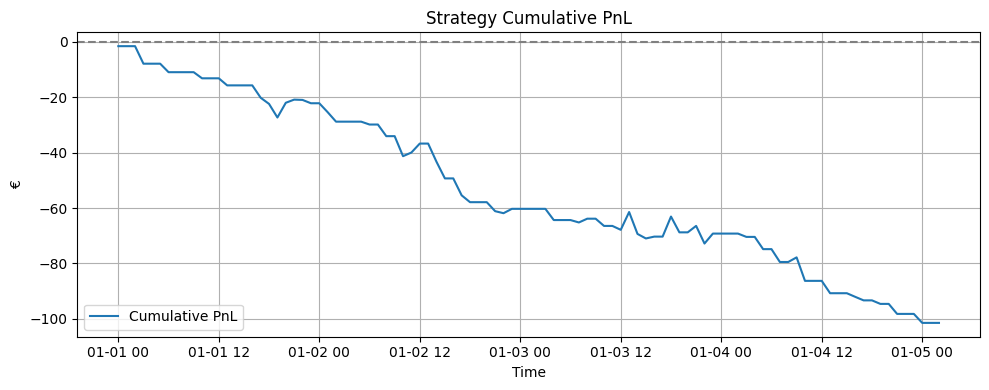

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["cumulative_pnl"], label="Cumulative PnL")
plt.axhline(0, linestyle='--', color='gray')
plt.title("Strategy Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("€")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

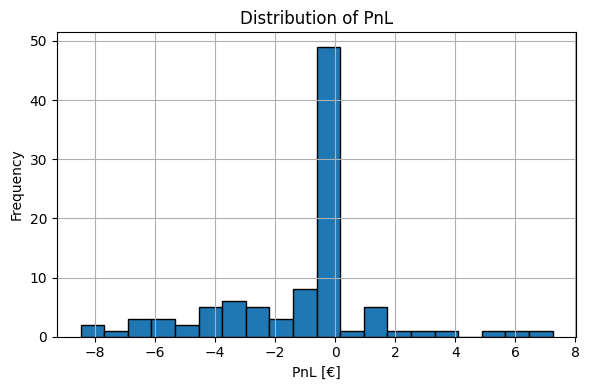

In [22]:
plt.figure(figsize=(6, 4))
plt.hist(pnl, bins=20, edgecolor='k')
plt.title("Distribution of PnL")
plt.xlabel("PnL [€]")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
t_stat, p_value = stats.ttest_1samp(pnl, popmean=0)
print(f"t-test: t = {t_stat:.2f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("Strategy PnL is statistically significant (p < 0.05)")
else:
    print("Strategy PnL is NOT statistically significant")

t-test: t = -3.75, p = 0.0003
Strategy PnL is statistically significant (p < 0.05)


- If p < 0.05: PnL is statistically significant 

In [29]:
split = int(0.7 * len(df))
train_pnl = df["pnl"].iloc[:split]
test_pnl = df["pnl"].iloc[split:]

print("\nTrain/Test Validation:")
print(f"Train Sharpe: {train_pnl.mean() / train_pnl.std():.2f}")
print(f"Test Sharpe:  {test_pnl.mean() / test_pnl.std():.2f}")


Train/Test Validation:
Train Sharpe: -0.34
Test Sharpe:  -0.48


- IfTrain ≈ Test performance: No overfitting, robust model